### Imports Necessary Modules

In [59]:
import os
import glob
import re
import numpy as np
import pandas as pd
from dataclasses import dataclass
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import pipeline
import tensorflow_datasets as tfds
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Loading and preparing the IMDB movie review dataset

In [33]:
# Configuration
@dataclass
class Config:
    MAX_LEN = 256
    BATCH_SIZE = 32
    LR = 0.001
    VOCAB_SIZE = 30000
    EMBED_DIM = 128
    NUM_HEAD = 8
    FF_DIM = 128
    NUM_LAYERS = 1

config = Config()

# Download IMDB dataset
if not os.path.exists("aclImdb"):
    !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz

# Load text data
def get_text_list_from_files(files):
    texts = []
    for file in files:
        with open(file, encoding="utf-8") as f:
            texts += [line.strip() for line in f]
    return texts

def get_data_from_text_files(folder_name):
    pos_files = glob.glob(f"aclImdb/{folder_name}/pos/*.txt")
    neg_files = glob.glob(f"aclImdb/{folder_name}/neg/*.txt")
    pos_texts = get_text_list_from_files(pos_files)
    neg_texts = get_text_list_from_files(neg_files)
    df = pd.DataFrame({
        "review": pos_texts + neg_texts,
        "sentiment": [1]*len(pos_texts) + [0]*len(neg_texts)
    })
    return df.sample(len(df)).reset_index(drop=True)

train_df = get_data_from_text_files("train")
test_df = get_data_from_text_files("test")
all_data = pd.concat([train_df, test_df], ignore_index=True)

print(train_df.head())
print(test_df.head())
print(all_data.sample(5))

                                              review  sentiment
0  How could I best express my feelings about thi...          0
1  I gave this 4 stars because it has a lot of in...          0
2  Sean, you know I think that you are absolutely...          0
3  This movie introduces quite an array of charac...          0
4  This movie is perfect for families to watch to...          1
                                              review  sentiment
0  Fear and Desire is of interest mainly to Kubri...          0
1  I was expecting to this to be hilarious and it...          0
2  This isn't exactly a complicated story. It's n...          0
3  I watched this movie purely for the setting. I...          0
4  I heard that after the first Oceans movie, the...          1
                                                  review  sentiment
6098   Like others, I have seen and studied most of t...          1
1464   Four tales of terror regarding the events at a...          1
43191  This is a VERY underr

Head of Dataset:
                                              review  sentiment
0  How could I best express my feelings about thi...          0
1  I gave this 4 stars because it has a lot of in...          0
2  Sean, you know I think that you are absolutely...          0
3  This movie introduces quite an array of charac...          0
4  This movie is perfect for families to watch to...          1


/tmp/ipython-input-775460497.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=all_data, palette="Set2")


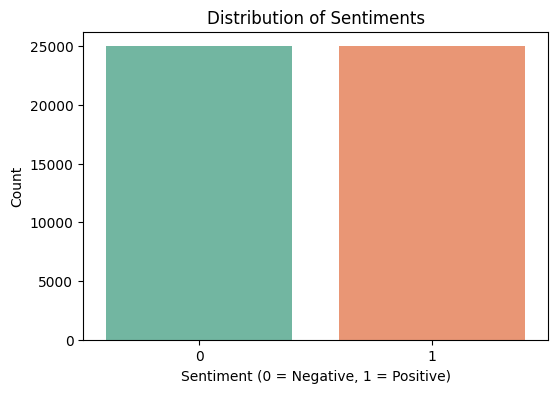

In [34]:
# Dataset Visualization
print("Head of Dataset:")
print(all_data.head())

# Count of positive vs negative reviews
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=all_data, palette="Set2")
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()


### Text Vectorization

In [35]:
def custom_standardization(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, "<br />", " ")
    return tf.strings.regex_replace(text, r"[%s]" % re.escape("!#$%&'()*+,-./:;<=>?@^_`{|}~"), "")

vectorize_layer = layers.TextVectorization(
    max_tokens=config.VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=config.MAX_LEN,
    standardize=custom_standardization
)
vectorize_layer.adapt(all_data.review.values)
mask_token_id = config.VOCAB_SIZE - 1

def encode(texts):
    return vectorize_layer(tf.convert_to_tensor(texts, dtype=tf.string))


### Masked LM preparation

In [36]:
def get_masked_input_and_labels(encoded_texts, mask_prob=0.15):
    encoded_texts = tf.cast(encoded_texts, tf.int64)
    seq_shape = tf.shape(encoded_texts)
    rand_vals = tf.random.uniform(seq_shape)
    inp_mask = tf.logical_and(rand_vals < mask_prob, encoded_texts > 2)

    labels = tf.identity(encoded_texts)
    masked_input = tf.identity(encoded_texts)

    mask_choice = tf.logical_and(inp_mask, tf.random.uniform(seq_shape) < 0.9)
    masked_input = tf.where(mask_choice, mask_token_id, masked_input)

    random_choice = tf.logical_and(mask_choice, tf.random.uniform(seq_shape) < (1/9))
    random_tokens = tf.random.uniform(seq_shape, minval=3, maxval=mask_token_id, dtype=tf.int64)
    masked_input = tf.where(random_choice, random_tokens, masked_input)

    sample_weights = tf.cast(inp_mask, tf.float32)
    return masked_input, labels, sample_weights

x_all_review = encode(all_data.review.values)
x_masked_train, y_masked_labels, sample_weights = get_masked_input_and_labels(x_all_review)
mlm_ds = tf.data.Dataset.from_tensor_slices((x_masked_train, y_masked_labels, sample_weights)).shuffle(1000).batch(config.BATCH_SIZE)


In [37]:
# Visualization
sample_texts = all_data.review.values[:1]
encoded = encode(sample_texts)

masked_input, labels, sample_weights = get_masked_input_and_labels(encoded)

masked_input = masked_input.numpy()
labels = labels.numpy()
sample_weights = sample_weights.numpy()

vocab = vectorize_layer.get_vocabulary()

for i in range(1):
    print(f"\n=== Sample {i+1} ===")
    print("Original:", sample_texts[i])

    masked_words = [vocab[id] if sample_weights[i,j]==0 else f"[MASK]" if id==mask_token_id else vocab[id]
                    for j,id in enumerate(masked_input[i]) if id != 0]
    print("Masked input:", " ".join(masked_words))

    label_words = [vocab[id] for j,id in enumerate(labels[i]) if id != 0]
    print("Labels       :", " ".join(label_words))

    print("Weights      :", sample_weights[i][:len(masked_words)])



=== Sample 1 ===
Original: How could I best express my feelings about this movie: hideous? a headache? lack of coherent writing? plain stupidity? Try all of the above for this travesty. And that just for the direction.<br /><br />Story? Well I guess there is a story. Two dumb blondes look for a job after they crash a plane into a golf course. They are mistaken for a 'world renounced assassin' (sarcasm) and are 'hired' by two 'mobsters'. One thinks "taking him out" means a date, and the other gets the minor actor she dreams of. And of course, the turtle reserve for the farting turtle, that they build with the casino winnings.<br /><br />Sounds likes all this could be funny? Guess again. They try to make it funny, but its not. Filming sequences aren't well done. I've seen better filming in Hong Kong movies. Visuals are average for a late 80s film. But the problem is that its a 2007 movie.<br /><br />Not worth my time to ever watch this again. It still doesn't beat Danny Glover's "Out" m

### Positional Embedding

In [62]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)

    # Add get_config for robust serialization
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

### BERT Module

In [39]:
def bert_module(query, key, value):
    attention = layers.MultiHeadAttention(num_heads=config.NUM_HEAD, key_dim=config.EMBED_DIM // config.NUM_HEAD)(query, key, value)
    attention = layers.LayerNormalization(epsilon=1e-6)(query + attention)
    ffn = keras.Sequential([layers.Dense(config.FF_DIM, activation="relu"), layers.Dense(config.EMBED_DIM)])
    ffn_output = ffn(attention)
    ffn_output = layers.LayerNormalization(epsilon=1e-6)(attention + ffn_output)
    return ffn_output

# Build MLM Backbone
def build_mlm_backbone():
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    x = PositionalEmbedding(config.MAX_LEN, config.VOCAB_SIZE, config.EMBED_DIM)(inputs)
    for _ in range(config.NUM_LAYERS):
        x = bert_module(x, x, x)
    outputs = layers.Dense(config.VOCAB_SIZE, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="mlm_backbone")

class MaskedLanguageModel(keras.Model):
    def __init__(self, backbone, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def call(self, x, training=False):
        return self.backbone(x, training=training)

    def train_step(self, data):
        x, y, w = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss_per_token = keras.losses.sparse_categorical_crossentropy(y, y_pred)
            weighted_loss = loss_per_token * w
            loss = tf.reduce_sum(weighted_loss) / (tf.reduce_sum(w) + 1e-8)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

backbone = build_mlm_backbone()
print("========== MLM Backbone Summary ==========")
backbone.summary()

mlm_model = MaskedLanguageModel(backbone)
mlm_model.compile(optimizer=keras.optimizers.Adam(config.LR))
history = mlm_model.fit(mlm_ds, epochs=10)

backbone.save("mlm_backbone.keras")


========== MLM Backbone Summary ==========


Model: "mlm_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 256, 128)  │  3,872,768 │ input_layer_6[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 128)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 256, 128)  │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256,       │  3,870,000 │ layer_normalizat… │
│                     │ 30000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,842,352 (29.92 MB)

 Trainable params: 7,842,352 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 86ms/step - loss: 7.1262
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - loss: 6.3588
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - loss: 6.0127
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - loss: 5.7534
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - loss: 5.5645
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - loss: 5.4061
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - loss: 5.2575
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - loss: 5.1206
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - loss: 4.9831
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - loss: 4.8482


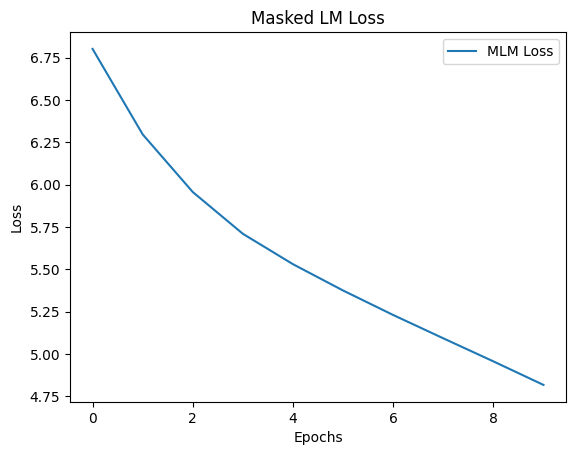

In [40]:
# Loss for MLM
plt.plot(history.history["loss"], label="MLM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Masked LM Loss")
plt.legend()
plt.show()

### Load and Prepare the SNLI Dataset

In [ ]:
# Load the dataset using tensorflow_datasets
snli_ds, info = tfds.load("snli", split="train", with_info=True)
val_ds = tfds.load("snli", split="validation")
test_ds = tfds.load("snli", split="test")

# The labels are: 0 (entailment), 1 (neutral), 2 (contradiction)
def format_and_tokenize(dataset, vectorizer):
    def preprocess(sample):
        combined_text = tf.strings.join([sample['premise'], sample['hypothesis']], separator=" [SEP] ")
        return vectorizer(combined_text), sample['label']

    dataset = dataset.filter(lambda x: x['label'] != -1)
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(config.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Prepare the data splits. Use smaller subsets for a quick demonstration.
train_snli = format_and_tokenize(snli_ds.take(20000), vectorize_layer)
val_snli = format_and_tokenize(val_ds.take(2000), vectorize_layer)
test_snli = format_and_tokenize(test_ds.take(2000), vectorize_layer)
print("SNLI data prepared.")

SNLI data prepared.


###  Build and Fine-Tune the Similarity Model

In [ ]:
def build_similarity_model(config):
    # Load the pre-trained backbone model
    pretrained_backbone = keras.models.load_model(
        "mlm_backbone.keras",
        custom_objects={"PositionalEmbedding": PositionalEmbedding}
    )

    # Extract the encoder part (all layers except the final MLM prediction head)
    encoder = keras.Model(
        pretrained_backbone.input, pretrained_backbone.layers[-2].output
    )
    encoder.trainable = False  

    # Build a new model on top of the frozen encoder
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    sequence_output = encoder(inputs)

    # For classification, we use the output of the first token ([CLS]), which acts as an aggregate representation
    pooled_output = sequence_output[:, 0, :]

    # Add a classification head with 3 outputs for the 3 SNLI labels
    outputs = layers.Dense(3, activation="softmax")(pooled_output)

    model = keras.Model(inputs, outputs)

    # Compile with a smaller learning rate for fine-tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.LR / 5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

similarity_model = build_similarity_model(config)
similarity_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_25 (Functional)      │ (None, 256, 128)       │     3,972,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,972,739 (15.15 MB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 3,972,352 (15.15 MB)

### Training

In [ ]:
print("\nStarting fine-tuning for Semantic Similarity...")
history_sim = similarity_model.fit(
    train_snli,
    epochs=30,
    validation_data=val_snli
)



Starting fine-tuning for Semantic Similarity...
Epoch 1/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.3437 - loss: 1.6381 - val_accuracy: 0.3347 - val_loss: 1.4909
Epoch 2/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3468 - loss: 1.4215 - val_accuracy: 0.3378 - val_loss: 1.3547
Epoch 3/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3496 - loss: 1.3123 - val_accuracy: 0.3439 - val_loss: 1.2787
Epoch 4/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3520 - loss: 1.2477 - val_accuracy: 0.3510 - val_loss: 1.2318
Epoch 5/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3560 - loss: 1.2064 - val_accuracy: 0.3474 - val_loss: 1.2005
Epoch 6/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3644 - loss: 1.1784 - val_accuracy: 0.3536 - val_loss: 1.1785
Epoch 7/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3656 - loss: 1.1586 - val_accuracy: 0.3454 - val_loss: 1.1625
Epoch 8/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/ste


Evaluating fine-tuned model...
Our Model Test Accuracy: 0.3809


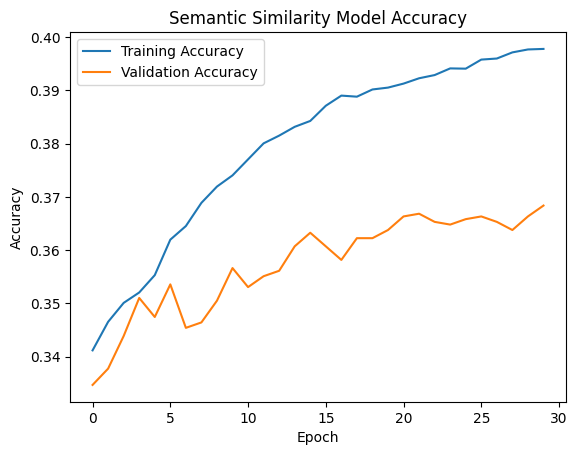

In [ ]:
# Evaluate and Visualize
print("\nEvaluating fine-tuned model...")
test_results = similarity_model.evaluate(test_snli, return_dict=True, verbose=0)
print(f"Our Model Test Accuracy: {test_results['accuracy']:.4f}")

# Plot history
plt.plot(history_sim.history['accuracy'], label='Training Accuracy')
plt.plot(history_sim.history['val_accuracy'], label='Validation Accuracy')
plt.title('Semantic Similarity Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

###  Inference Example

In [ ]:
# Inference Example 
def check_similarity(sentence1, sentence2):
    input_text = tf.constant([f"{sentence1} [SEP] {sentence2}"])
    tokenized_input = vectorize_layer(input_text)
    prediction = similarity_model.predict(tokenized_input, verbose=0)
    label_index = np.argmax(prediction[0])
    labels = {0: "Entailment (Similar)", 1: "Neutral", 2: "Contradiction (Dissimilar)"}

    print(f"Sentence 1: '{sentence1}'")
    print(f"Sentence 2: '{sentence2}'")
    print(f"--> Predicted Relationship: {labels[label_index]}")

print("\n--- INFERENCE EXAMPLES ---")
check_similarity("A man is playing a guitar.", "A man is performing music.")
print("-" * 30)
check_similarity("A child is eating a piece of cake.", "The child is hungry.")
print("-" * 30)
check_similarity("A woman is walking her dog in the park.", "The woman is at home.")


--- INFERENCE EXAMPLES ---
Sentence 1: 'A man is playing a guitar.'
Sentence 2: 'A man is performing music.'
--> Predicted Relationship: Neutral
------------------------------
Sentence 1: 'A child is eating a piece of cake.'
Sentence 2: 'The child is hungry.'
--> Predicted Relationship: Neutral
------------------------------
Sentence 1: 'A woman is walking her dog in the park.'
Sentence 2: 'The woman is at home.'
--> Predicted Relationship: Contradiction (Dissimilar)


### Evalution and Comparison


--- Evaluating 'Our Model' ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Our Model Test Accuracy: 0.3809

--- Evaluating Public Model ---


Device set to use cuda:0


Evaluating public model on 2000 samples...
Public model (DistilBERT MNLI) accuracy: 0.7610


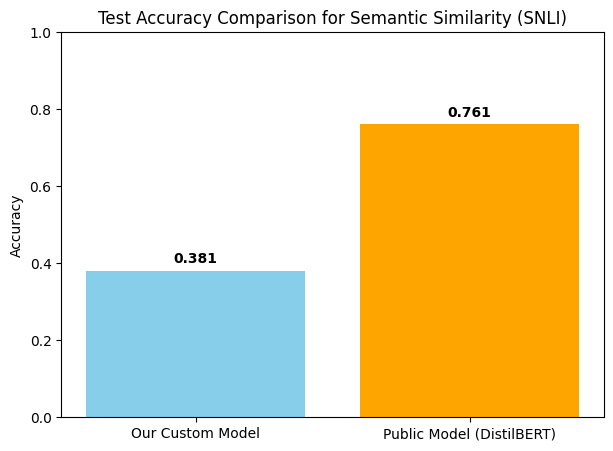

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

#  EVALUATE FINE-TUNED CUSTOM MODEL
print("--- Evaluating 'Our Model' ---")
our_model_results = similarity_model.evaluate(test_snli, return_dict=True, verbose=0)
our_model_accuracy = our_model_results['accuracy']
print(f"Our Model Test Accuracy: {our_model_accuracy:.4f}")


# EVALUATE THE PUBLIC MODEL USING THE 'text-classification' PIPELINE
print("\n--- Evaluating Public Model ---")
# Use the text-classification pipeline with the specified NLI model
pipe = pipeline("text-classification", model="typeform/distilbert-base-uncased-mnli", device=0)

subset_size = 2000
# Prepare the data in the format the pipeline expects
premises_subset = [sample['premise'].numpy().decode('utf-8') for sample in test_ds.take(subset_size)]
hypotheses_subset = [sample['hypothesis'].numpy().decode('utf-8') for sample in test_ds.take(subset_size)]
y_test_subset = [sample['label'].numpy() for sample in test_ds.take(subset_size)]

# The NLI model expects the premise and hypothesis concatenated with a [SEP] token
public_input_texts = [p + " [SEP] " + h for p, h in zip(premises_subset, hypotheses_subset)]

print(f"Evaluating public model on {len(public_input_texts)} samples...")
# Run predictions in batches for efficiency
public_predictions_raw = pipe(public_input_texts, batch_size=64)

# SNLI labels: 0=entailment, 1=neutral, 2=contradiction
label_map = {'ENTAILMENT': 0, 'NEUTRAL': 1, 'CONTRADICTION': 2}
pred_labels = [label_map.get(p['label']) for p in public_predictions_raw]

# Compute accuracy
public_model_accuracy = accuracy_score(y_test_subset, pred_labels)
print(f"Public model (DistilBERT MNLI) accuracy: {public_model_accuracy:.4f}")


# VISUAL COMPARISON
plt.figure(figsize=(7, 5))
plt.bar(
    ['Our Custom Model', 'Public Model (DistilBERT)'],
    [our_model_accuracy, public_model_accuracy],
    color=['skyblue', 'orange']
)
plt.title('Test Accuracy Comparison for Semantic Similarity (SNLI)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for i, acc in enumerate([our_model_accuracy, public_model_accuracy]):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')

plt.show()